# Avellaneda-Stoikov Market Making

$$r = S - q\,\gamma\,\sigma^2\,(T-t) \qquad \delta^* = \frac{\gamma\sigma^2(T-t)}{2} + \frac{1}{\gamma}\ln\!\left(1+\frac{\gamma}{\kappa}\right)$$

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from market_making import AvellanedaStoikov, ASSimulator
from order_book    import LOBGenerator

## 1. Analytical formulas

AvellanedaStoikov(gamma=0.1, sigma=2.0, kappa=1.5, T=1.0)
  spread t=0: 1.69077   spread t=T: 1.29077


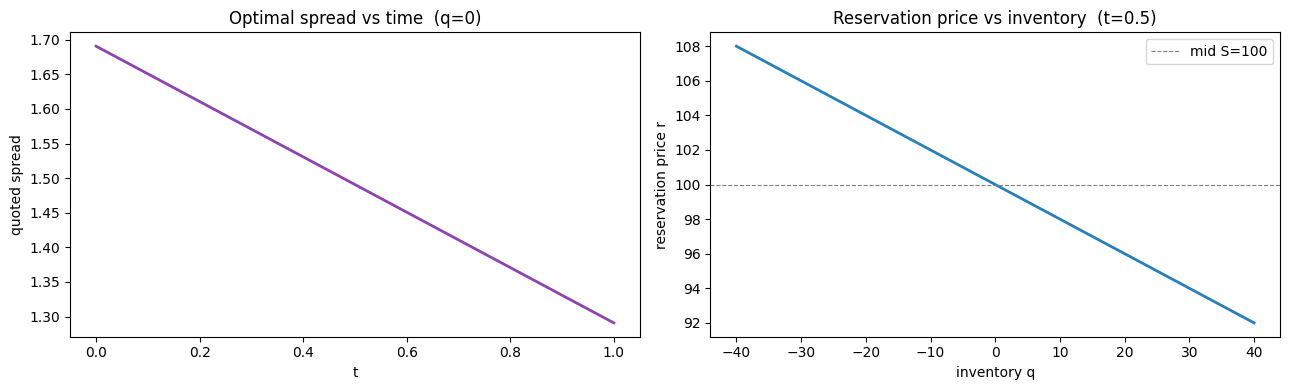

In [2]:
strat = AvellanedaStoikov(gamma=0.1, sigma=2.0, kappa=1.5, T=1.0)
print(strat)

times = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

spreads = [2 * strat.optimal_half_spread(t) for t in times]
axes[0].plot(times, spreads, color='#8e44ad', lw=2)
axes[0].set_xlabel('t')
axes[0].set_ylabel('quoted spread')
axes[0].set_title('Optimal spread vs time  (q=0)')

inv_range = np.linspace(-40, 40, 300)
r_prices  = [strat.reservation_price(100.0, q, 0.5) for q in inv_range]
axes[1].plot(inv_range, r_prices, color='#2980b9', lw=2)
axes[1].axhline(100.0, color='gray', ls='--', lw=0.8, label='mid S=100')
axes[1].set_xlabel('inventory q')
axes[1].set_ylabel('reservation price r')
axes[1].set_title('Reservation price vs inventory  (t=0.5)')
axes[1].legend()

plt.tight_layout()
plt.show()

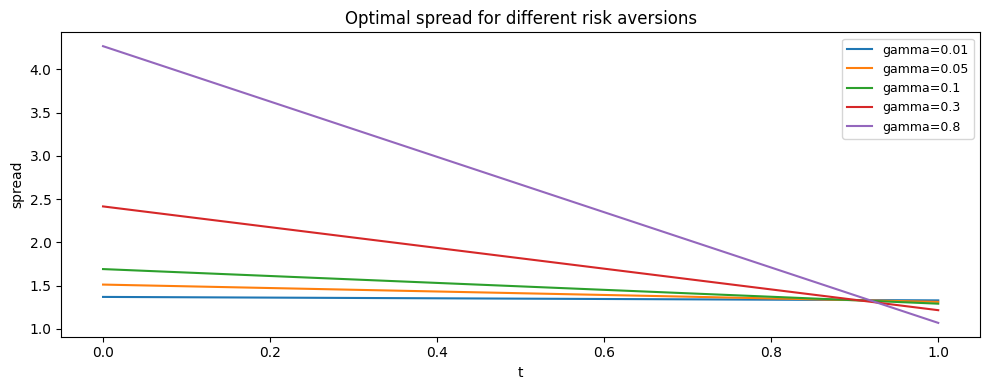

In [3]:
# spread as a function of gamma
gammas = [0.01, 0.05, 0.1, 0.3, 0.8]
fig, ax = plt.subplots(figsize=(10, 4))
for g in gammas:
    s  = AvellanedaStoikov(gamma=g, sigma=2.0, kappa=1.5, T=1.0)
    sp = [2 * s.optimal_half_spread(t) for t in times]
    ax.plot(times, sp, lw=1.5, label=f'gamma={g}')
ax.set_xlabel('t')
ax.set_ylabel('spread')
ax.set_title('Optimal spread for different risk aversions')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2. Full simulation

In [4]:
GAMMA = 0.1
SIGMA = 0.2
KAPPA = 1.5
T_SIM = 100.0

# tuned empirically -- higher rate + wider depth so AS quotes actually get hit
MU = np.array([4.5, 4.5, 1.2, 1.2, 0.9, 0.9])

strat  = AvellanedaStoikov(gamma=GAMMA, sigma=SIGMA, kappa=KAPPA, T=T_SIM)
gen    = LOBGenerator(mid0=100.0, sigma_mid=0.05, qty_mean=12.0,
                      depth_scale=4.0, mu=MU, seed=42)
sim    = ASSimulator(strat, gen, T=T_SIM, requote_dt=0.5, lot_size=5.0,
                     max_inventory=50.0, record_every=1, seed=42)

result = sim.run()
print(result.summary())

final PnL=+24.2336  |inv|_max=5.6  fills=41  sharpe=0.595


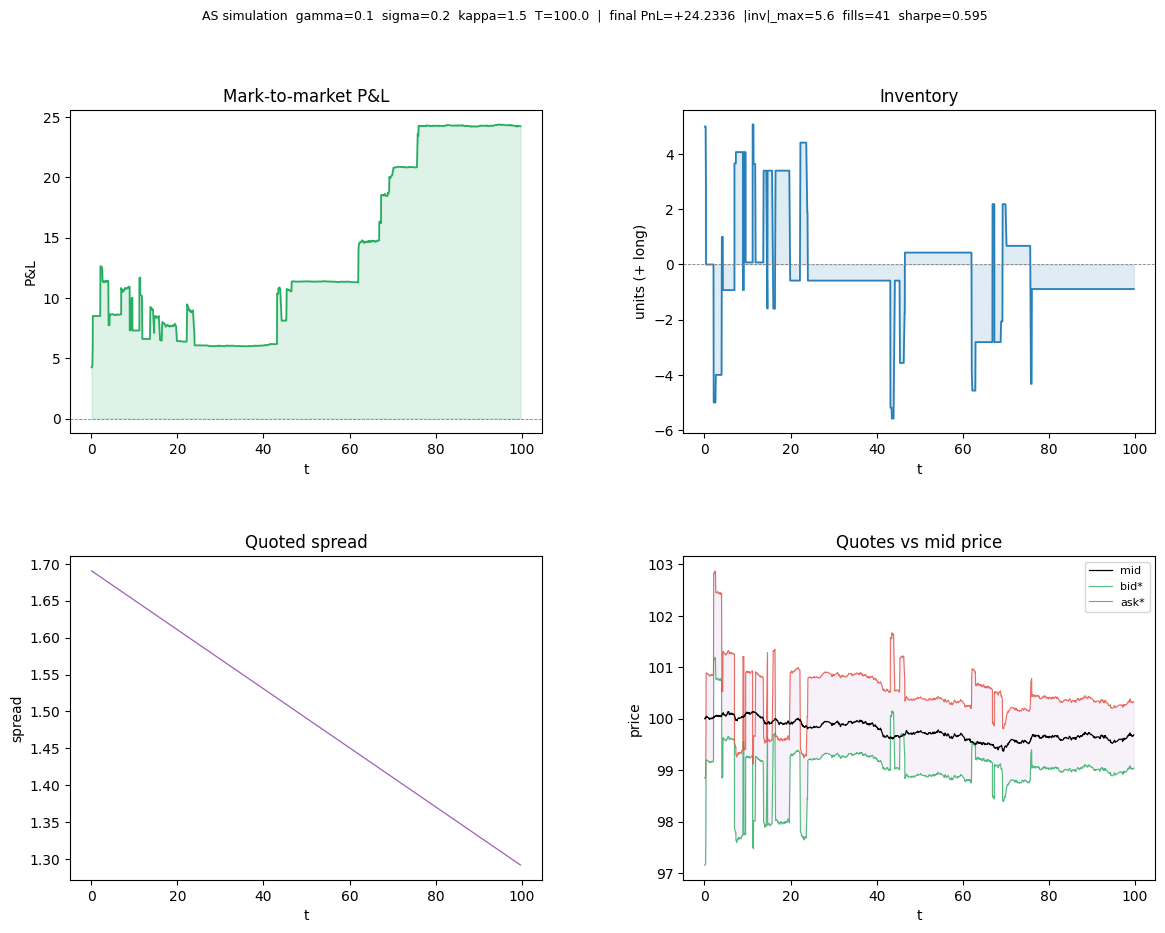

In [5]:
t_p, pnl        = result.pnl_series()
t_i, inv        = result.inventory_series()
t_s, spreads    = result.spread_series()
t_b, bids, asks = result.bid_ask_series()
_,   mids       = result.mid_series()

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.30)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t_p, pnl, color='#27ae60', lw=1.3)
ax0.axhline(0, color='gray', lw=0.6, ls='--')
ax0.fill_between(t_p, pnl, 0, where=pnl >= 0, alpha=0.15, color='#27ae60')
ax0.fill_between(t_p, pnl, 0, where=pnl <  0, alpha=0.15, color='#e74c3c')
ax0.set_title('Mark-to-market P&L')
ax0.set_xlabel('t')
ax0.set_ylabel('P&L')

ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t_i, inv, color='#2980b9', lw=1.3)
ax1.axhline(0, color='gray', lw=0.6, ls='--')
ax1.fill_between(t_i, inv, 0, alpha=0.15, color='#2980b9')
ax1.set_title('Inventory')
ax1.set_xlabel('t')
ax1.set_ylabel('units (+ long)')

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t_s, spreads, color='#8e44ad', lw=0.9, alpha=0.85)
ax2.set_title('Quoted spread')
ax2.set_xlabel('t')
ax2.set_ylabel('spread')

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_b, mids, color='black', lw=0.9, label='mid', zorder=3)
ax3.plot(t_b, bids, color='#27ae60', lw=0.8, alpha=0.8, label='bid*')
ax3.plot(t_b, asks, color='#e74c3c', lw=0.8, alpha=0.8, label='ask*')
ax3.fill_between(t_b, bids, asks, alpha=0.07, color='#8e44ad')
ax3.set_title('Quotes vs mid price')
ax3.set_xlabel('t')
ax3.set_ylabel('price')
ax3.legend(fontsize=8)

plt.suptitle(
    f'AS simulation  gamma={GAMMA}  sigma={SIGMA}  kappa={KAPPA}  T={T_SIM}  |  {result.summary()}',
    fontsize=9
)
plt.show()

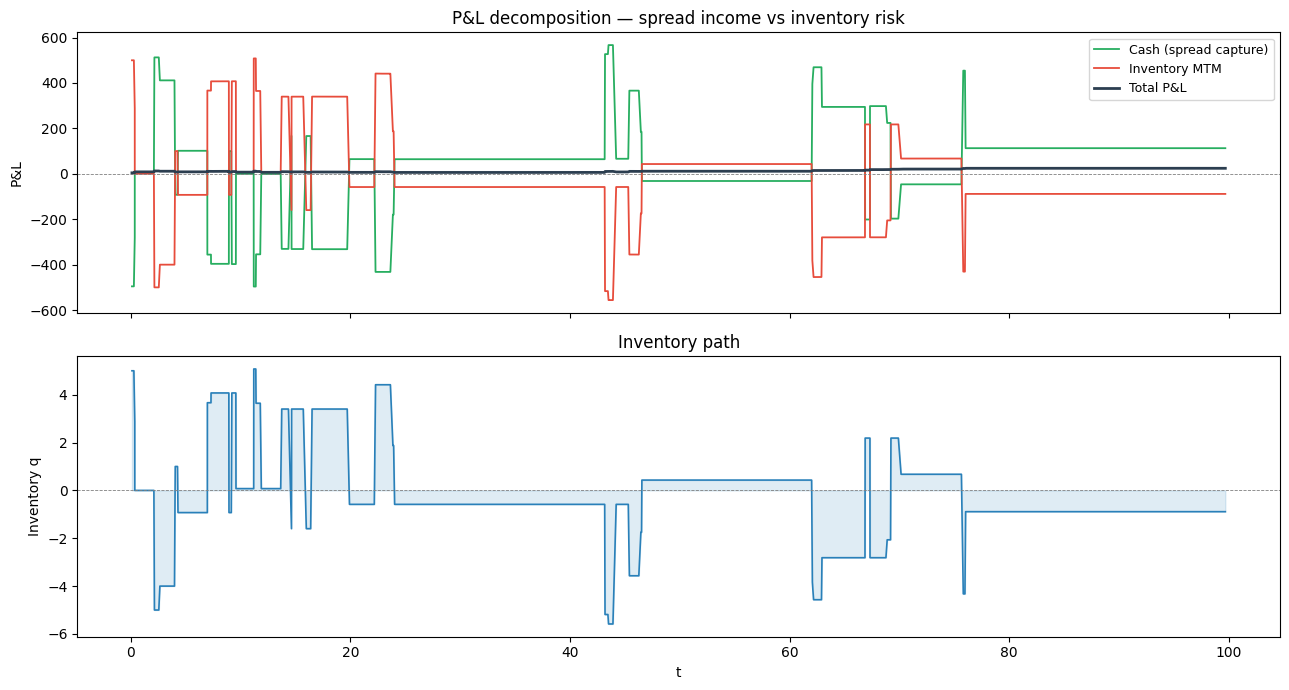

In [6]:
# cash increases at each fill (bid-ask spread captured)
# inventory MTM fluctuates with mid price -- source of risk

t_d   = np.array([s.timestamp for s in result.steps])
cash  = np.array([s.cash      for s in result.steps])
inv   = np.array([s.inventory for s in result.steps])
mid_  = np.array([s.mid       for s in result.steps])
total = np.array([s.pnl       for s in result.steps])
inv_mtm = inv * mid_

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t_d, cash,    color='#27ae60', lw=1.3, label='Cash (spread capture)')
axes[0].plot(t_d, inv_mtm, color='#e74c3c', lw=1.3, label='Inventory MTM')
axes[0].plot(t_d, total,   color='#2c3e50', lw=2.0, label='Total P&L', zorder=3)
axes[0].axhline(0, color='gray', lw=0.6, ls='--')
axes[0].set_ylabel('P&L')
axes[0].set_title('P&L decomposition — spread income vs inventory risk')
axes[0].legend(fontsize=9)

axes[1].plot(t_d, inv, color='#2980b9', lw=1.2)
axes[1].axhline(0, color='gray', lw=0.6, ls='--')
axes[1].fill_between(t_d, inv, 0, alpha=0.15, color='#2980b9')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Inventory q')
axes[1].set_title('Inventory path')

plt.tight_layout()
plt.show()

## 3. Sensitivity to gamma

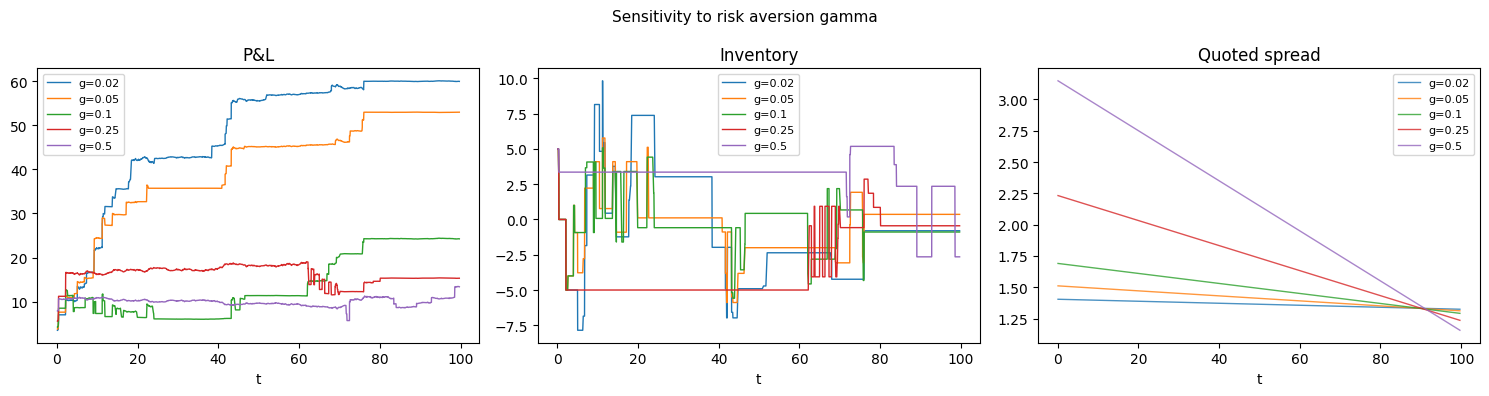

In [7]:
gammas  = [0.02, 0.05, 0.1, 0.25, 0.5]
results = {}

for g in gammas:
    s  = AvellanedaStoikov(gamma=g, sigma=SIGMA, kappa=KAPPA, T=T_SIM)
    gn = LOBGenerator(mid0=100.0, sigma_mid=0.05, qty_mean=12.0,
                      depth_scale=4.0, mu=MU, seed=42)
    sm = ASSimulator(s, gn, T=T_SIM, requote_dt=0.5, lot_size=5.0,
                     max_inventory=50.0, record_every=1, seed=42)
    results[g] = sm.run()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for g, res in results.items():
    tp, pnl = res.pnl_series()
    ti, inv = res.inventory_series()
    ts, sp  = res.spread_series()
    axes[0].plot(tp, pnl, lw=1,        label=f'g={g}')
    axes[1].plot(ti, inv, lw=1,        label=f'g={g}')
    axes[2].plot(ts, sp,  lw=1, alpha=0.8, label=f'g={g}')

axes[0].set_title('P&L');           axes[0].legend(fontsize=8)
axes[1].set_title('Inventory');     axes[1].legend(fontsize=8)
axes[2].set_title('Quoted spread'); axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel('t')

plt.suptitle('Sensitivity to risk aversion gamma', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
print(f'{"gamma":>8}  {"final PnL":>12}  {"|inv| max":>10}  {"fills":>7}  {"sharpe":>8}')
print('-' * 55)
for g, res in results.items():
    print(f'{g:>8.3f}  {res.final_pnl:>+12.4f}  {res.max_inventory:>10.2f}  {res.n_fills:>7d}  {res.sharpe:>8.3f}')

   gamma     final PnL   |inv| max    fills    sharpe
-------------------------------------------------------
   0.020      +59.9540        9.83       33     1.849
   0.050      +52.9663        5.89       38     1.579
   0.100      +24.2336        5.58       41     0.595
   0.250      +15.3001        5.00       26     0.335
   0.500      +13.3630        5.18       12     0.355
